<a href="https://colab.research.google.com/github/m3llad0/fake_news_detection/blob/main/Fake_news_detection_model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Fake news detection model

Model to detected fake news in Spanish using BETO

In [ ]:
!pip install torch-geometric


In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.optim import AdamW
from torch.utils.data import DataLoader, TensorDataset
from torch.optim import AdamW # Import AdamW
from torch_geometric.utils import dense_to_sparse # Import dense_to_sparse
from torch_geometric.nn import GATConv # Import GATConv

import torch.nn.functional as F

from transformers import AutoTokenizer, AutoModel
from sklearn.preprocessing import LabelEncoder, MinMaxScaler, label_binarize
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score

import numpy as np
import pandas as pd

import gc
import requests

from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import LabelEncoder, MinMaxScaler
from sklearn.metrics import classification_report, accuracy_score, f1_score
from sklearn.metrics.pairwise import cosine_similarity
from textblob import TextBlob
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_auc_score, roc_curve, auc


In [ ]:
# Dispositivo (GPU si disponible)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using:", device)


Using: cuda


In [ ]:
# API endpoint
ROUTE = "https://my-thesis-aaacd0bxgzfae8a0.westus-01.azurewebsites.net/dataset"

# Fetch the data
response = requests.get(ROUTE)
data = response.json()

# Extract 'Scrapped news' list
news_items = data["Scrapped news"]

# Convert to DataFrame
df = pd.DataFrame(news_items)

# Preprocess the dataset for model input
df['label'] = df['VERACIDAD'].map({'true': 0, 'false': 1, "satira":2})  # Map veracity to binary labels


df.drop(["METADATA", "VERACIDAD"], axis=1, inplace=True)

df.head()


,AUTOR,CORPUS,FECHA,TITULO,URL,label
0,Heraldo De Aragón,La Universidad de Oxford lanza en España su nu...,2017-04-05 00:00:00,Oxford lanza sus propios exámenes de certifica...,https://www.heraldo.es/noticias/sociedad/2017/...,0
1,Ernesto Agudo,"Darío Villanueva, director de la RAE, en una r...",2018-06-26 13:51:37+02:00,La RAE estudia incluir «machirulo» en el Dicci...,https://www.abc.es/cultura/abci-estudia-inclui...,0
2,"Pedro, Villa Y Caña, Pedro Villa Y Caña, Ver P...",Estudiantes de la F acultad de Ciencias Políti...,,Realizan paro en Facultad de Ciencias Política...,http://www.eluniversal.com.mx/nacion/sociedad/...,0
3,Dios De La Guerra Y Referente Del Humor Period...,This post has already been read 3168 times!\n\...,2018-01-18 08:47:27+00:00,Deniegan el B1 a un joven mudo por no poder ap...,https://haynoticia.es/deniegan-b1-joven-mudo-n...,1
4,Yako Daniel,"El señor Jorge Vergara, dueño del Club Guada...",2016-06-30 01:19:18+00:00,Jorge Vergara recapacita y ofrece precios más ...,https://www.eldizque.com/jorge-vergara-recapac...,1


# Data augmentation




In [ ]:
from transformers import pipeline
import random, pandas as pd, requests

# Load BETO masked LM
fill_mask = pipeline("fill-mask", model="dccuchile/bert-base-spanish-wwm-cased", top_k=3)

def augment_text(text, mask_prob=0.15):
    """Replace ~15% of words with BETO predictions."""
    words = text.split()
    if len(words) < 5: return text
    n = max(1, int(len(words) * mask_prob))
    for i in random.sample(range(len(words)), n):
        words[i] = "[MASK]"
    masked = " ".join(words)
    try:
        preds = fill_mask(masked)
        if isinstance(preds, list):
            for p in preds:
                masked = masked.replace("[MASK]", p['token_str'], 1)
        return masked
    except:
        return text

# Apply augmentation to 30% of dataset (skip satire if desired)
subset = df[df["label"] != 2].sample(frac=0.3, random_state=42)
aug_df = subset.copy()
aug_df["CORPUS"] = aug_df["CORPUS"].apply(augment_text)

# Merge and shuffle
df = pd.concat([df, aug_df], ignore_index=True).sample(frac=1, random_state=42).reset_index(drop=True)
print(f"✅ Data Augmentation complete: added {len(aug_df)} samples (total {len(df)})")
df.head()


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(
Device set to use cuda:0
Token indices sequence length is longer than the specified maximum sequence length for this model (835 > 512). Running this sequence through the model will result in indexing errors
You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset


✅ Data Augmentation complete: added 260 samples (total 1559)


,AUTOR,CORPUS,FECHA,TITULO,URL,label
0,Yako Daniel,Santo y Blue Demon son las figuras más represe...,2019-04-08 22:03:42+00:00,"Santo y Blue Demon sí perdieron las máscaras, ...",https://www.eldizque.com/santo-y-blue-demon-si...,1
1,"Redacción El Universal, Ver Perfil","Juan Carlos, el pequeño niño oaxaqueño que fue...",2017-04-12 00:00:00,Conmueve a Juan Carlos apoyo en MasterChef,http://www.eluniversal.com.mx/articulo/especta...,0
2,J. Jesús Esquivel,WASHINGTON (apro).- La victoria electoral de A...,,El extraño acercamiento de Trump a AMLO,https://www.proceso.com.mx/541584/el-extrano-a...,0
3,Anna Nicolaou,"Lachlan Murdoch, el director ejecutivo de Fox ...",2021-02-15 00:00:01,Fox News no cederá a su postura política ante ...,https://www.milenio.com/negocios/financial-tim...,0
4,"Gustavo Rugeles, Director De El Expediente",A comienzos de éste año todos los medios de co...,2019-10-02 15:39:08+00:00,"Video: redadas en el banco Vaticano, el Diacon...",https://elexpediente.co/video-redadas-el-banco...,1


In [ ]:

def sentiment(x):
    return TextBlob(str(x)).sentiment.polarity


In [ ]:
from transformers import TextClassificationPipeline, AutoModelForSequenceClassification

cb_tok = AutoTokenizer.from_pretrained("taniwasl/clickbait_es")
cb_mod = AutoModelForSequenceClassification.from_pretrained("taniwasl/clickbait_es")
cb_pipe = TextClassificationPipeline(model=cb_mod, tokenizer=cb_tok, return_all_scores=True)


Device set to use cuda:0
/usr/local/lib/python3.12/dist-packages/transformers/pipelines/text_classification.py:111: UserWarning: `return_all_scores` is now deprecated,  if want a similar functionality use `top_k=None` instead of `return_all_scores=True` or `top_k=1` instead of `return_all_scores=False`.
  warnings.warn(


In [ ]:
from urllib.parse import urlparse
import numpy as np
import pandas as pd
import re


def type_token_ratio(text):
    tokens = text.split()
    if len(tokens) == 0:
        return 0
    return len(set(tokens)) / len(tokens)

def caps_ratio(text):
    caps = sum(1 for c in text if c.isupper())
    return caps / max(len(text),1)

def excl_ratio(text):
    excl = text.count('!')
    return excl / max(len(text),1)

def clickbait_score(txt):
    res = cb_pipe(txt[:256])[0]
    return [x for x in res if "click" in x['label'].lower()][0]['score']

In [ ]:
from urllib.parse import urlparse
import numpy as np
import pandas as pd
import re

df['longitud'] = df['CORPUS'].str.split().str.len().astype(float)
df['polarity'] = df['CORPUS'].apply(sentiment)
df['clickbait'] = df['TITULO'].apply(clickbait_score)
df['fuente'] = df['AUTOR'].fillna("desconocido")
df['domain'] = df['URL'].apply(lambda x: urlparse(x).netloc)

# Explicitly convert 'FECHA' to datetime with error handling and UTC
df['FECHA'] = pd.to_datetime(df['FECHA'], errors='coerce', utc=True)
df['year']    = df['FECHA'].dt.year.fillna(0).astype(int) # Fill NaT with 0 and cast to int
df['month']   = df['FECHA'].dt.month.fillna(0).astype(int) # Fill NaT with 0 and cast to int


df['title_len']  = df['TITULO'].str.len()
df['title_excl'] = df['TITULO'].str.count('!')

df['ttr']        = df['CORPUS'].apply(type_token_ratio)
df['caps_ratio'] = df['CORPUS'].apply(caps_ratio)
df['excl_ratio'] = df['CORPUS'].apply(excl_ratio)

In [ ]:
tokenizer = AutoTokenizer.from_pretrained(
    "dccuchile/bert-base-spanish-wwm-cased"
)

In [ ]:
def get_cls_embeddings(texts, model, batch=8):
    enc = tokenizer(list(texts), truncation=True, padding=True, max_length=256, return_tensors='pt')
    ds = torch.utils.data.TensorDataset(enc['input_ids'], enc['attention_mask'])
    dl = torch.utils.data.DataLoader(ds, batch_size=batch)

    model.eval()
    out = []
    with torch.no_grad():
        for ix,mask in dl:
            ix,mask = ix.to(device),mask.to(device)
            h = model(input_ids=ix, attention_mask=mask)
            out.append(h.last_hidden_state[:,0,:].cpu().numpy())
    return np.vstack(out)


In [ ]:
# class HybridGAT(nn.Module):
#     def __init__(self, meta_dim, text_dim=768, hidden=64):
#         super().__init__()
#         self.meta_fc = nn.Linear(meta_dim, 64)
#         self.gat = GATConv(64, 32, heads=2, concat=False)
#         self.fc1 = nn.Linear(text_dim + 32, hidden)
#         self.fc2 = nn.Linear(hidden, 3)
#         self.drop = nn.Dropout(0.5)

#     def forward(self, meta, txt, edge_index):
#         m = F.relu(self.meta_fc(meta))
#         m = self.gat(m, edge_index)
#         x = torch.cat([m, txt], dim=1)
#         x = F.relu(self.fc1(x))
#         x = self.drop(x)
#         return self.fc2(x)


In [ ]:
class HybridGAT(nn.Module):
    def __init__(self, meta_dim=0):
        super().__init__()

        # GAT input: 768 dims (BETO CLS vector)
        self.gat1 = GATConv(768, 64, heads=4, concat=True)
        self.gat2 = GATConv(64*4, 64, heads=1, concat=False)

        # texto-only = 64 -> 3 clases
        self.cls = nn.Linear(64, 3)

        # si en el futuro usas metadata
        if meta_dim > 0:
            self.meta_fc = nn.Linear(meta_dim, 32)
            self.cls = nn.Linear(64 + 32, 3)

        self.meta_dim = meta_dim

    def forward(self, meta, text, edge_index):

        # --- rama texto ---
        x = self.gat1(text, edge_index)
        x = F.relu(x)
        x = self.gat2(x, edge_index)
        x = F.relu(x)

        # --- rama metadata (opcional) ---
        if self.meta_dim > 0 and meta is not None:
            m = self.meta_fc(meta)
            m = F.relu(m)
            x = torch.cat([x, m], dim=1)

        out = self.cls(x)
        return out

In [ ]:
class FocalLoss(nn.Module):
    def __init__(self, gamma=2.0, alpha=None, reduction='mean'):
        super().__init__()
        self.gamma = gamma
        self.alpha = alpha
        self.reduction = reduction

    def forward(self, logits, targets):
        # logits: (N, C) sin softmax
        # targets: (N,)
        ce = F.cross_entropy(logits, targets, reduction='none')
        pt = torch.exp(-ce)  # prob. bien clasificada
        focal = (1 - pt)**self.gamma * ce

        if self.alpha is not None:
            focal = self.alpha * focal

        if self.reduction == 'mean':
            return focal.mean()
        elif self.reduction == 'sum':
            return focal.sum()
        return focal

In [ ]:
from sklearn.preprocessing import LabelEncoder, MinMaxScaler
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score
from sklearn.preprocessing import label_binarize
from torch_geometric.utils import dense_to_sparse

import matplotlib.pyplot as plt

skf = StratifiedKFold(n_splits=8, shuffle=True, random_state=42)

acc_scores = []
f1_scores  = []
all_preds = []
all_trues = []
all_probs = []

# PARA LEARNING CURVES GLOBALES
fold_train_curves = []
fold_val_curves = []

y = df['label'].values

for fold, (train_idx, test_idx) in enumerate(skf.split(df, y)):

    print(f"\n=== Fold {fold+1} ===")

    df_tr = df.iloc[train_idx].copy()
    df_te = df.iloc[test_idx].copy()

    # =======================
    # CV-SAFE ENCODERS
    # =======================
    le_domain = LabelEncoder().fit(df_tr['domain'])
    df_tr['domain_enc'] = le_domain.transform(df_tr['domain'])
    df_te['domain_enc'] = df_te['domain'].map(lambda x: le_domain.transform([x])[0] if x in le_domain.classes_ else -1)

    le_autor = LabelEncoder().fit(df_tr['AUTOR'])
    df_tr['autor_enc'] = le_autor.transform(df_tr['AUTOR'])
    df_te['autor_enc'] = df_te['AUTOR'].map(lambda x: le_autor.transform([x])[0] if x in le_autor.classes_ else -1)

    le_corpus = LabelEncoder().fit(df_tr['CORPUS'])
    df_tr['corpus_enc'] = le_corpus.transform(df_tr['CORPUS'])
    df_te['corpus_enc'] = df_te['CORPUS'].map(lambda x: le_corpus.transform([x])[0] if x in le_corpus.classes_ else -1)

    # =======================
    # METADATA NUMÉRICA
    # =======================
    meta_cols = [
        'domain_enc','autor_enc','corpus_enc',
        'year','month',
        'longitud','polarity','clickbait',
        'title_len','title_excl',
        'excl_ratio','caps_ratio','ttr'
    ]

    scaler = MinMaxScaler().fit(df_tr[meta_cols])
    Xtr_meta = scaler.transform(df_tr[meta_cols])
    Xte_meta = scaler.transform(df_te[meta_cols])

    # =======================
    # TOKENIZACIÓN
    # =======================
    tr_enc = tokenizer(list(df_tr['CORPUS']), truncation=True, padding=True, max_length=256, return_tensors="pt").to(device)
    te_enc = tokenizer(list(df_te['CORPUS']), truncation=True, padding=True, max_length=256, return_tensors="pt").to(device)

    ytr = torch.tensor(df_tr['label'].values, dtype=torch.long).to(device)
    yte = torch.tensor(df_te['label'].values, dtype=torch.long).to(device)

    # =======================
    # BETO
    # =======================
    beto = AutoModel.from_pretrained("dccuchile/bert-base-spanish-wwm-cased").to(device)

    # congela capas inferiores
    for name, param in beto.named_parameters():
        if any(f"encoder.layer.{i}" in name for i in range(6)):
            param.requires_grad = False

    cls_head = nn.Linear(768, 3).to(device)
    opt = AdamW(list(beto.parameters()) + list(cls_head.parameters()), lr=2e-5)
    crit = nn.CrossEntropyLoss(label_smoothing=0.1)

    train_loader = DataLoader(
        TensorDataset(tr_enc['input_ids'], tr_enc['attention_mask'], ytr),
        batch_size=8, shuffle=True
    )

    scaler = torch.cuda.amp.GradScaler()

    # === TRAIN BETO ===
    beto.train(); cls_head.train()

    for epoch in range(3):
        for input_ids, attn, labels in train_loader:
            opt.zero_grad()
            with torch.cuda.amp.autocast():
                out = beto(input_ids=input_ids, attention_mask=attn)
                cls_vec = out.last_hidden_state[:,0,:]
                logits = cls_head(cls_vec)
                loss = crit(logits, labels)
            scaler.scale(loss).backward()
            scaler.step(opt)
            scaler.update()

    # =======================
    # EXTRAER EMBEDDINGS
    # =======================
    beto.eval(); cls_head.eval()

    with torch.no_grad():
        Xtr_txt = beto(**tr_enc).last_hidden_state[:,0,:].cpu().numpy()
        Xte_txt = beto(**te_enc).last_hidden_state[:,0,:].cpu().numpy()

    X_all_txt = np.vstack([Xtr_txt, Xte_txt])
    meta_all  = np.vstack([Xtr_meta, Xte_meta])


    # =======================
    # MULTI-VIEW GRAPH
    # =======================
    sim_text = cosine_similarity(X_all_txt) ** 2
    sim_domain = (np.equal.outer(meta_all[:,0], meta_all[:,0])).astype(np.float32)
    sim_time   = (np.abs(np.subtract.outer(meta_all[:,3], meta_all[:,3])) <= 1).astype(np.float32)

    sim = (sim_text + sim_domain + sim_time) / 3.0

    np.fill_diagonal(sim, 0)
    sim = np.maximum(sim, sim.T)

    # k-NN
    k = 8
    idx = np.argsort(sim, axis=1)[:, :-k]
    for i, rows in enumerate(idx):
        sim[i, rows] = 0

    adj = torch.tensor(sim, dtype=torch.float32)
    edge_index, _ = dense_to_sparse(adj)
    edge_index = edge_index.to(device)

    # =======================
    # TENSORES
    # =======================
    t_all    = torch.tensor(X_all_txt, dtype=torch.float32).to(device)
    meta_all = torch.tensor(meta_all, dtype=torch.float32).to(device)
    y_all    = torch.tensor(np.concatenate([df_tr['label'], df_te['label']]), dtype=torch.long).to(device)

    num_train = len(df_tr)
    train_nodes = torch.arange(num_train, device=device)
    test_nodes  = torch.arange(num_train, num_train + len(df_te), device=device)

    # =======================
    # HybridGAT
    # =======================
    model = HybridGAT(meta_dim=meta_all.shape[1]).to(device)
    gnn_opt = optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-3)
    crit2 = nn.CrossEntropyLoss(label_smoothing=0.1)

    # ====== ARRAYS PARA CURVAS ======
    train_losses = []
    val_losses = []
    train_accs = []
    val_accs = []

    # =======================
    # TRAIN GNN
    # =======================
    for epoch in range(12):
        model.train()
        gnn_opt.zero_grad()
        logits = model(meta_all, t_all, edge_index)[train_nodes]
        loss2 = crit2(logits, y_all[train_nodes])

        # Train accuracy
        pred_train = logits.argmax(dim=1)
        acc_train = accuracy_score(y_all[train_nodes].cpu(), pred_train.cpu())

        loss2.backward()
        gnn_opt.step()

        # VALIDACIÓN
        model.eval()
        with torch.no_grad():
            logits_v = model(meta_all, t_all, edge_index)[test_nodes]
            loss_v = crit2(logits_v, y_all[test_nodes])
            pred_v = logits_v.argmax(dim=1)
            acc_v = accuracy_score(y_all[test_nodes].cpu(), pred_v.cpu())

        train_losses.append(loss2.item())
        val_losses.append(loss_v.item())
        train_accs.append(acc_train)
        val_accs.append(acc_v)

    fold_train_curves.append((train_losses, val_losses))

    # =======================
    # FINAL TEST
    # =======================
    model.eval()
    with torch.no_grad():
        logits_te = model(meta_all, t_all, edge_index)[test_nodes]
        pred = logits_te.argmax(dim=1).cpu().numpy()
        probs = logits_te.softmax(dim=1).cpu().numpy()
        true = y_all[test_nodes].cpu().numpy()

    acc = accuracy_score(true, pred)
    f1  = f1_score(true, pred, average='macro')

    acc_scores.append(acc)
    f1_scores.append(f1)

    all_preds.extend(pred)
    all_trues.extend(true)
    all_probs.append(probs)

    print(f"Acc={acc:.3f}  F1={f1:.3f}")

    # limpieza
    del beto, cls_head, model, sim
    del tr_enc, te_enc, train_loader
    torch.cuda.empty_cache()
    gc.collect()


# =======================
# MÉTRICAS FINALES
# =======================
all_probs = np.vstack(all_probs)
all_trues = np.array(all_trues)
y_bin = label_binarize(all_trues, classes=[0,1,2])

roc_macro = roc_auc_score(y_bin, all_probs, average='macro', multi_class='ovr')

print("\nAUC-ROC (macro):", round(roc_macro,4))
print("\nAccuracy CV:", np.mean(acc_scores), "±", np.std(acc_scores))
print("Macro-F1 CV:", np.mean(f1_scores), "±", np.std(f1_scores))



=== Fold 1 ===


Some weights of BertModel were not initialized from the model checkpoint at dccuchile/bert-base-spanish-wwm-cased and are newly initialized: ['pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
/tmp/ipython-input-1134762184.py:88: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler()
/tmp/ipython-input-1134762184.py:96: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():


Acc=0.918  F1=0.917

=== Fold 2 ===


Some weights of BertModel were not initialized from the model checkpoint at dccuchile/bert-base-spanish-wwm-cased and are newly initialized: ['pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
/tmp/ipython-input-1134762184.py:88: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler()
/tmp/ipython-input-1134762184.py:96: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():


Acc=0.928  F1=0.932

=== Fold 3 ===


...

Acc=0.892  F1=0.894

=== Fold 7 ===


Some weights of BertModel were not initialized from the model checkpoint at dccuchile/bert-base-spanish-wwm-cased and are newly initialized: ['pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
/tmp/ipython-input-1134762184.py:88: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler()
/tmp/ipython-input-1134762184.py:96: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():


Acc=0.892  F1=0.895

=== Fold 8 ===


Some weights of BertModel were not initialized from the model checkpoint at dccuchile/bert-base-spanish-wwm-cased and are newly initialized: ['pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
/tmp/ipython-input-1134762184.py:88: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler()
/tmp/ipython-input-1134762184.py:96: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():


Acc=0.902  F1=0.905

AUC-ROC (macro): 0.9835

Accuracy CV: 0.9076295268305579 ± 0.016438704226894044
Macro-F1 CV: 0.9100812928406395 ± 0.016083577764363515


In [ ]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import roc_auc_score, accuracy_score, f1_score
import matplotlib.pyplot as plt
import numpy as np

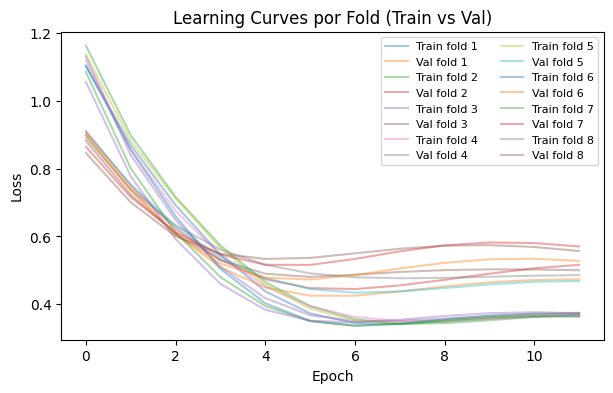

In [ ]:
plt.figure(figsize=(7,4))
for i,(tr,vl) in enumerate(fold_train_curves):
    plt.plot(tr, alpha=0.4, label=f'Train fold {i+1}')
    plt.plot(vl, alpha=0.4, label=f'Val fold {i+1}')
plt.title("Learning Curves por Fold (Train vs Val)")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend(ncol=2, fontsize=8)
plt.show()


<Figure size 500x500 with 0 Axes>

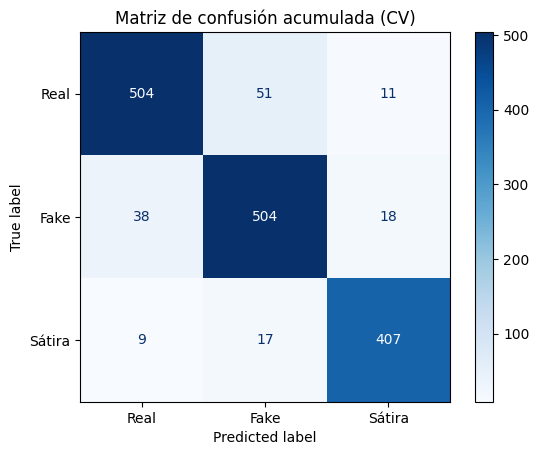

In [ ]:
cm = confusion_matrix(all_trues, all_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                              display_labels=["Real","Fake","Sátira"])
plt.figure(figsize=(5,5))
disp.plot(cmap='Blues')
plt.title("Matriz de confusión acumulada (CV)")
plt.grid(False)
plt.show()


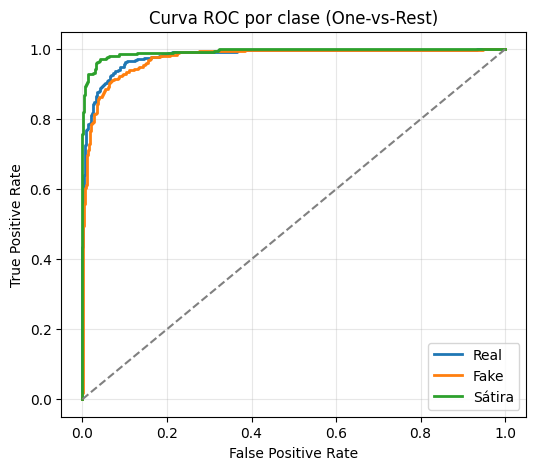

In [ ]:
plt.figure(figsize=(6,5))

for i, cls in enumerate(["Real","Fake","Sátira"]):
    fpr, tpr, _ = roc_curve(y_bin[:,i], all_probs[:,i])
    plt.plot(fpr, tpr, lw=2, label=f"{cls}")

plt.plot([0,1],[0,1],'--',color='gray')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Curva ROC por clase (One-vs-Rest)")
plt.legend()
plt.grid(alpha=.3)
plt.show()


/tmp/ipython-input-1344775178.py:2: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([acc_scores, f1_scores], labels=["Accuracy","Macro-F1"])


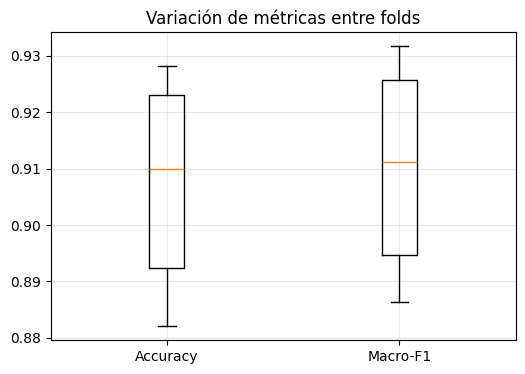

In [ ]:
plt.figure(figsize=(6,4))
plt.boxplot([acc_scores, f1_scores], labels=["Accuracy","Macro-F1"])
plt.title("Variación de métricas entre folds")
plt.grid(alpha=0.3)
plt.show()


In [ ]:
print("\n🚀 Retraining final model on full dataset...")

# Re-encode categorical variables
le_domain = LabelEncoder().fit(df['domain'])
le_autor  = LabelEncoder().fit(df['AUTOR'])
le_corpus = LabelEncoder().fit(df['CORPUS'])
df['domain_enc'] = le_domain.transform(df['domain'])
df['autor_enc']  = le_autor.transform(df['AUTOR'])
df['corpus_enc'] = le_corpus.transform(df['CORPUS'])

# Metadata
meta_cols = [
    'domain_enc','autor_enc','corpus_enc',
    'year','month',
    'longitud','polarity','clickbait',
    'title_len','title_excl',
    'excl_ratio','caps_ratio','ttr'
]
scaler = MinMaxScaler().fit(df[meta_cols])
X_meta = scaler.transform(df[meta_cols])

# BETO tokenization & embeddings
tokenizer = AutoTokenizer.from_pretrained("dccuchile/bert-base-spanish-wwm-cased")
enc = tokenizer(list(df['CORPUS']), truncation=True, padding=True, max_length=256, return_tensors="pt").to(device)
y_all = torch.tensor(df['label'].values, dtype=torch.long).to(device)

beto = AutoModel.from_pretrained("dccuchile/bert-base-spanish-wwm-cased").to(device)
for name, p in beto.named_parameters():
    if any(f"encoder.layer.{i}" in name for i in range(6)):
        p.requires_grad = False

cls_head = nn.Linear(768, 3).to(device)
opt = AdamW(list(beto.parameters()) + list(cls_head.parameters()), lr=2e-5)
crit = nn.CrossEntropyLoss(label_smoothing=0.1)

train_loader = DataLoader(TensorDataset(enc['input_ids'], enc['attention_mask'], y_all),
                          batch_size=8, shuffle=True)
scaler_amp = torch.cuda.amp.GradScaler()

beto.train(); cls_head.train()
for epoch in range(3):
    for input_ids, attn, labels in train_loader:
        opt.zero_grad()
        with torch.cuda.amp.autocast():
            out = beto(input_ids=input_ids, attention_mask=attn)
            cls_vec = out.last_hidden_state[:, 0, :]
            logits = cls_head(cls_vec)
            loss = crit(logits, labels)
        scaler_amp.scale(loss).backward()
        scaler_amp.step(opt)
        scaler_amp.update()

# Extract embeddings for graph
beto.eval()
with torch.no_grad():
    X_txt = beto(**enc).last_hidden_state[:, 0, :].cpu().numpy()

# Build similarity graph
sim_text = cosine_similarity(X_txt) ** 2
sim_domain = (np.equal.outer(X_meta[:,0], X_meta[:,0])).astype(np.float32)
sim_time   = (np.abs(np.subtract.outer(X_meta[:,3], X_meta[:,3])) <= 1).astype(np.float32)
sim = (sim_text + sim_domain + sim_time) / 3.0
np.fill_diagonal(sim, 0)
sim = np.maximum(sim, sim.T)

# Keep strongest k edges
k = 8
for i in range(sim.shape[0]):
    weakest = np.argsort(sim[i])[:-k]
    sim[i, weakest] = 0

adj = torch.tensor(sim, dtype=torch.float32)
edge_index, _ = dense_to_sparse(adj)
edge_index = edge_index.to(device)

# Train GNN
t_all = torch.tensor(X_txt, dtype=torch.float32).to(device)
meta_all = torch.tensor(X_meta, dtype=torch.float32).to(device)

model = HybridGAT(meta_dim=meta_all.shape[1]).to(device)
opt_gnn = optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-3)
crit_gnn = nn.CrossEntropyLoss(label_smoothing=0.1)

for epoch in range(12):
    model.train()
    opt_gnn.zero_grad()
    logits = model(meta_all, t_all, edge_index)
    loss = crit_gnn(logits, y_all)
    loss.backward()
    opt_gnn.step()

print("✅ Final model trained successfully!")



🚀 Retraining final model on full dataset...


Some weights of BertModel were not initialized from the model checkpoint at dccuchile/bert-base-spanish-wwm-cased and are newly initialized: ['pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
/tmp/ipython-input-3618103378.py:38: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler_amp = torch.cuda.amp.GradScaler()
/tmp/ipython-input-3618103378.py:44: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():


✅ Final model trained successfully!


# Pruebas del modelo

In [ ]:

import pickle
from datetime import datetime
from urllib.parse import urlparse
from pathlib import Path
from typing import List, Dict, Union, Tuple, Optional

class FakeNewsClassifier:
    """
    Hybrid GNN-BETO Fake News Classifier

    A complete classifier that combines BETO (Spanish BERT) for text understanding
    with Graph Attention Networks (GAT) for contextual information propagation.

    Attributes:
        device (torch.device): Computing device (CPU or CUDA)
        model (HybridGAT): Trained GNN model
        beto (AutoModel): Fine-tuned BETO model
        tokenizer (AutoTokenizer): BETO tokenizer
        clickbait_pipeline: Clickbait detection pipeline
        label_encoders (dict): Label encoders for categorical features
        scaler (MinMaxScaler): Feature scaler
        train_embeddings (dict): Training data embeddings and features
        trained_graph (torch.Tensor): Original trained graph structure
        label_map (dict): Mapping from numeric labels to text
    """

    def __init__(self, device: Optional[torch.device] = None):
        """
        Initialize the classifier.

        Parameters:
            device: Computing device. If None, automatically selects CUDA if available.
        """
        self.device = device or torch.device("cuda" if torch.cuda.is_available() else "cpu")
        print(f"🖥️  Using device: {self.device}")

        # Model components (to be loaded)
        self.model = None
        self.beto = None
        self.tokenizer = None
        self.clickbait_pipeline = None

        # Preprocessing components
        self.label_encoders = {
            'domain': None,
            'autor': None,
            'corpus': None
        }
        self.scaler = None

        # Training data (for graph extension)
        self.train_embeddings = {
            'text': None,
            'meta': None
        }
        self.trained_graph = None

        # Label mapping
        self.label_map = {0: 'Real', 1: 'Fake', 2: 'Sátira'}
        self.reverse_label_map = {'Real': 0, 'Fake': 1, 'Sátira': 2}

        # Metadata columns (must match training)
        self.meta_cols = [
            'domain_enc', 'autor_enc', 'corpus_enc',
            'year', 'month',
            'longitud', 'polarity', 'clickbait',
            'title_len', 'title_excl',
            'excl_ratio', 'caps_ratio', 'ttr'
        ]

    # =========================================================================
    # Model Management
    # =========================================================================

    def save(self, save_dir: Union[str, Path]) -> None:
        """
        Save all model components to directory.

        Parameters:
            save_dir: Directory path to save model components
        """
        save_dir = Path(save_dir)
        save_dir.mkdir(parents=True, exist_ok=True)

        # Save model weights
        torch.save(self.model.state_dict(), save_dir / 'hybrid_gat_model.pth')
        torch.save(self.beto.state_dict(), save_dir / 'beto_finetuned.pth')

        # Save preprocessing components
        components = {
            'le_domain': self.label_encoders['domain'],
            'le_autor': self.label_encoders['autor'],
            'le_corpus': self.label_encoders['corpus'],
            'scaler': self.scaler,
            'train_text_embeddings': self.train_embeddings['text'],
            'train_meta_features': self.train_embeddings['meta'],
            'trained_edge_index': self.trained_graph.cpu() if self.trained_graph is not None else None,
            'meta_dim': self.train_embeddings['meta'].shape[1] if self.train_embeddings['meta'] is not None else 0
        }

        with open(save_dir / 'model_components.pkl', 'wb') as f:
            pickle.dump(components, f)

        print(f"✅ Model saved successfully to {save_dir}")

    def load(self, load_dir: Union[str, Path], model_class) -> None:
        """
        Load all model components from directory.

        Parameters:
            load_dir: Directory path containing model components
            model_class: HybridGAT class definition (needed to instantiate model)
        """
        load_dir = Path(load_dir)

        # Load preprocessing components
        with open(load_dir / 'model_components.pkl', 'rb') as f:
            components = pickle.load(f)

        self.label_encoders['domain'] = components['le_domain']
        self.label_encoders['autor'] = components['le_autor']
        self.label_encoders['corpus'] = components['le_corpus']
        self.scaler = components['scaler']
        self.train_embeddings['text'] = components['train_text_embeddings']
        self.train_embeddings['meta'] = components['train_meta_features']
        self.trained_graph = components['trained_edge_index']
        meta_dim = components['meta_dim']

        # Load tokenizer
        self.tokenizer = AutoTokenizer.from_pretrained("dccuchile/bert-base-spanish-wwm-cased")

        # Load clickbait pipeline
        cb_tok = AutoTokenizer.from_pretrained("taniwasl/clickbait_es")
        cb_mod = AutoModelForSequenceClassification.from_pretrained("taniwasl/clickbait_es")
        self.clickbait_pipeline = TextClassificationPipeline(
            model=cb_mod, tokenizer=cb_tok, return_all_scores=True
        )

        # Load BETO
        self.beto = AutoModel.from_pretrained("dccuchile/bert-base-spanish-wwm-cased").to(self.device)
        self.beto.load_state_dict(torch.load(load_dir / 'beto_finetuned.pth', map_location=self.device))
        self.beto.eval()

        # Load GNN model
        self.model = model_class(meta_dim=meta_dim).to(self.device)
        self.model.load_state_dict(torch.load(load_dir / 'hybrid_gat_model.pth', map_location=self.device))
        self.model.eval()

        print(f"✅ Model loaded successfully from {load_dir}")

    def initialize_from_training(self, model, beto, tokenizer, clickbait_pipeline,
                                le_domain, le_autor, le_corpus, scaler,
                                train_text_embeddings, train_meta_features,
                                trained_edge_index):
        """
        Initialize classifier with components from training session.
        Use this when you've just finished training and want to classify immediately.

        Parameters:
            model: Trained HybridGAT model
            beto: Fine-tuned BETO model
            tokenizer: BETO tokenizer
            clickbait_pipeline: Clickbait detection pipeline
            le_domain, le_autor, le_corpus: Label encoders
            scaler: Feature scaler
            train_text_embeddings: Training text embeddings
            train_meta_features: Training metadata features
            trained_edge_index: Trained graph edge indices
        """
        self.model = model
        self.beto = beto
        self.tokenizer = tokenizer
        self.clickbait_pipeline = clickbait_pipeline

        self.label_encoders['domain'] = le_domain
        self.label_encoders['autor'] = le_autor
        self.label_encoders['corpus'] = le_corpus
        self.scaler = scaler

        self.train_embeddings['text'] = train_text_embeddings
        self.train_embeddings['meta'] = train_meta_features
        self.trained_graph = trained_edge_index

        print("✅ Classifier initialized from training session")

    # =========================================================================
    # Feature Engineering
    # =========================================================================

    @staticmethod
    def _sentiment(text: str) -> float:
        """Calculate sentiment polarity."""
        return TextBlob(str(text)).sentiment.polarity

    @staticmethod
    def _type_token_ratio(text: str) -> float:
        """Calculate vocabulary diversity."""
        tokens = text.split()
        return len(set(tokens)) / len(tokens) if len(tokens) > 0 else 0

    @staticmethod
    def _caps_ratio(text: str) -> float:
        """Calculate ratio of capital letters."""
        caps = sum(1 for c in text if c.isupper())
        return caps / max(len(text), 1)

    @staticmethod
    def _excl_ratio(text: str) -> float:
        """Calculate ratio of exclamation marks."""
        return text.count('!') / max(len(text), 1)

    def _clickbait_score(self, text: str) -> float:
        """Calculate clickbait probability."""
        res = self.clickbait_pipeline(text[:256])[0]
        return [x for x in res if "click" in x['label'].lower()][0]['score']

    def _extract_features(self, df: pd.DataFrame) -> pd.DataFrame:
        """
        Extract all features from raw news data.

        Parameters:
            df: DataFrame with raw news data

        Returns:
            DataFrame with extracted features
        """
        # Text-based features
        df['longitud'] = df['CORPUS'].str.split().str.len().astype(float)
        df['polarity'] = df['CORPUS'].apply(self._sentiment)
        df['clickbait'] = df['TITULO'].apply(self._clickbait_score)
        df['ttr'] = df['CORPUS'].apply(self._type_token_ratio)
        df['caps_ratio'] = df['CORPUS'].apply(self._caps_ratio)
        df['excl_ratio'] = df['CORPUS'].apply(self._excl_ratio)

        # Title features
        df['title_len'] = df['TITULO'].str.len()
        df['title_excl'] = df['TITULO'].str.count('!')

        # Source features
        df['fuente'] = df['AUTOR']
        df['domain'] = df['URL'].apply(lambda x: urlparse(x).netloc)

        # Temporal features
        df['FECHA'] = pd.to_datetime(df['FECHA'], errors='coerce')
        df['year'] = df['FECHA'].dt.year.fillna(datetime.now().year).astype(int)
        df['month'] = df['FECHA'].dt.month.fillna(datetime.now().month).astype(int)

        return df

    def _prepare_news_data(self, news_list: List[Dict]) -> pd.DataFrame:
        """
        Prepare and validate news data.

        Parameters:
            news_list: List of news dictionaries

        Returns:
            Prepared DataFrame
        """
        # Convert to DataFrame
        df = pd.DataFrame(news_list)

        # Validate required fields
        required_fields = ['TITULO', 'CORPUS']
        for field in required_fields:
            if field not in df.columns:
                raise ValueError(f"Missing required field: {field}")

        # Fill optional fields
        df['AUTOR'] = df.get('AUTOR', 'desconocido').fillna('desconocido')
        df['URL'] = df.get('URL', 'https://unknown.com').fillna('https://unknown.com')
        df['FECHA'] = df.get('FECHA', datetime.now().strftime('%Y-%m-%d'))

        # Extract features
        df = self._extract_features(df)

        return df

    def _encode_features(self, df: pd.DataFrame) -> np.ndarray:
        """
        Encode categorical features and scale numerical features.

        Parameters:
            df: DataFrame with extracted features

        Returns:
            Scaled metadata features
        """
        # Encode categorical features (handle unknown values)
        df['domain_enc'] = df['domain'].map(
            lambda x: self.label_encoders['domain'].transform([x])[0]
            if x in self.label_encoders['domain'].classes_ else -1
        )
        df['autor_enc'] = df['AUTOR'].map(
            lambda x: self.label_encoders['autor'].transform([x])[0]
            if x in self.label_encoders['autor'].classes_ else -1
        )
        df['corpus_enc'] = df['CORPUS'].map(
            lambda x: self.label_encoders['corpus'].transform([x])[0]
            if x in self.label_encoders['corpus'].classes_ else -1
        )

        # Scale features
        X_meta = self.scaler.transform(df[self.meta_cols])

        return X_meta

    def _extract_embeddings(self, df: pd.DataFrame) -> np.ndarray:
        """
        Extract BETO embeddings from text.

        Parameters:
            df: DataFrame with news text

        Returns:
            Text embeddings (CLS token representations)
        """
        # Tokenize
        enc = self.tokenizer(
            list(df['CORPUS']),
            truncation=True,
            padding=True,
            max_length=256,
            return_tensors="pt"
        ).to(self.device)

        # Extract embeddings
        self.beto.eval()
        with torch.no_grad():
            outputs = self.beto(**enc)
            embeddings = outputs.last_hidden_state[:, 0, :].cpu().numpy()

        return embeddings

    # =========================================================================
    # Graph Construction
    # =========================================================================

    def _extend_graph(self, X_new_txt: np.ndarray, X_new_meta: np.ndarray,
                     k: int = 8) -> Tuple[torch.Tensor, torch.Tensor, torch.Tensor]:
        """
        Extend trained graph with new nodes.

        Parameters:
            X_new_txt: Text embeddings of new nodes
            X_new_meta: Metadata features of new nodes
            k: Number of nearest neighbors to connect

        Returns:
            Tuple of (edge_index, all_text_features, all_meta_features)
        """
        X_train_txt = self.train_embeddings['text']
        X_train_meta = self.train_embeddings['meta']

        num_train = len(X_train_txt)
        num_new = len(X_new_txt)

        # Combine all features
        X_all_txt = np.vstack([X_train_txt, X_new_txt])
        X_all_meta = np.vstack([X_train_meta, X_new_meta])

        # Calculate multi-view similarity for new nodes
        sim_text = cosine_similarity(X_new_txt, X_all_txt) ** 2
        sim_domain = np.equal.outer(X_new_meta[:, 0], X_all_meta[:, 0]).astype(np.float32)
        sim_time = (np.abs(np.subtract.outer(X_new_meta[:, 3], X_all_meta[:, 3])) <= 1).astype(np.float32)

        # Combined similarity
        sim = (sim_text + sim_domain + sim_time) / 3.0

        # Build edges for new nodes
        new_edges_src = []
        new_edges_dst = []

        for i in range(num_new):
            new_idx = num_train + i
            node_sim = sim[i, :].copy()
            node_sim[new_idx] = 0  # Don't connect to itself

            # Get k nearest neighbors
            k_nearest = np.argsort(node_sim)[-k:]

            # Add bidirectional edges
            for neighbor in k_nearest:
                if node_sim[neighbor] > 0:
                    new_edges_src.extend([new_idx, neighbor])
                    new_edges_dst.extend([neighbor, new_idx])

        # Combine with trained edges
        if len(new_edges_src) > 0:
            new_edges = torch.tensor([new_edges_src, new_edges_dst], dtype=torch.long)
            extended_edge_index = torch.cat([self.trained_graph.cpu(), new_edges], dim=1)
        else:
            extended_edge_index = self.trained_graph.cpu()

        # Convert to tensors
        t_all = torch.tensor(X_all_txt, dtype=torch.float32)
        meta_all = torch.tensor(X_all_meta, dtype=torch.float32)

        return extended_edge_index, t_all, meta_all

    # =========================================================================
    # Prediction
    # =========================================================================

    def predict(self, news_list: List[Dict], k: int = 8,
                return_probabilities: bool = True, verbose: bool = True) -> pd.DataFrame:
        """
        Classify one or multiple news articles.

        Parameters:
            news_list: List of dictionaries, each containing:
                - 'TITULO': Title of the news (required)
                - 'CORPUS': Main text/body (required)
                - 'AUTOR': Author or source (optional)
                - 'URL': URL of the news (optional)
                - 'FECHA': Date in 'YYYY-MM-DD' format (optional)
            k: Number of nearest neighbors for graph connection
            return_probabilities: Whether to include class probabilities
            verbose: Whether to print progress messages

        Returns:
            DataFrame with classification results
        """
        # Validate model is loaded
        if self.model is None or self.beto is None:
            raise RuntimeError("Model not loaded. Call load() or initialize_from_training() first.")

        if verbose:
            print(f"🔍 Classifying {len(news_list)} news article(s)...")

        # Step 1: Prepare data
        if verbose:
            print("  📝 Preparing data...")
        df = self._prepare_news_data(news_list)

        # Step 2: Encode features
        if verbose:
            print("  🔢 Encoding features...")
        X_meta = self._encode_features(df)

        # Step 3: Extract embeddings
        if verbose:
            print("  🧠 Extracting embeddings...")
        X_txt = self._extract_embeddings(df)

        # Step 4: Extend graph
        if verbose:
            print("  🕸️  Extending graph...")
        edge_index, t_all, meta_all = self._extend_graph(X_txt, X_meta, k=k)

        # Move to device
        edge_index = edge_index.to(self.device)
        t_all = t_all.to(self.device)
        meta_all = meta_all.to(self.device)

        # Step 5: Make predictions
        if verbose:
            print("  🎯 Making predictions...")

        self.model.eval()
        num_train = len(self.train_embeddings['text'])
        new_nodes = torch.arange(num_train, num_train + len(df), device=self.device)

        with torch.no_grad():
            logits = self.model(meta_all, t_all, edge_index)[new_nodes]
            probs = logits.softmax(dim=1).cpu().numpy()
            preds = logits.argmax(dim=1).cpu().numpy()

        # Step 6: Format results
        results = pd.DataFrame({
            'Title': df['TITULO'].values,
            'Prediction': [self.label_map[p] for p in preds],
            'Confidence': np.max(probs, axis=1)
        })

        if return_probabilities:
            results['Prob_Real'] = probs[:, 0]
            results['Prob_Fake'] = probs[:, 1]
            results['Prob_Satira'] = probs[:, 2]

        if verbose:
            print("✅ Classification complete!\n")

        return results

    def predict_single(self, titulo: str, corpus: str,
                      autor: Optional[str] = None,
                      url: Optional[str] = None,
                      fecha: Optional[str] = None,
                      verbose: bool = True) -> Dict:
        """
        Classify a single news article with convenient interface.

        Parameters:
            titulo: Title of the news
            corpus: Main text/body
            autor: Author or source (optional)
            url: URL of the news (optional)
            fecha: Date in 'YYYY-MM-DD' format (optional)
            verbose: Whether to print progress

        Returns:
            Dictionary with classification results
        """
        news = [{
            'TITULO': titulo,
            'CORPUS': corpus,
            'AUTOR': autor or 'desconocido',
            'URL': url or 'https://unknown.com',
            'FECHA': fecha or datetime.now().strftime('%Y-%m-%d')
        }]

        result = self.predict(news, verbose=verbose)

        return {
            'prediction': result['Prediction'].iloc[0],
            'confidence': float(result['Confidence'].iloc[0]),
            'probabilities': {
                'Real': float(result['Prob_Real'].iloc[0]),
                'Fake': float(result['Prob_Fake'].iloc[0]),
                'Sátira': float(result['Prob_Satira'].iloc[0])
            }
        }

    # =========================================================================
    # Utility Methods
    # =========================================================================

    def get_model_info(self) -> Dict:
        """Get information about the loaded model."""
        if self.model is None:
            return {"status": "Model not loaded"}

        return {
            "status": "Model loaded",
            "device": str(self.device),
            "training_samples": len(self.train_embeddings['text']) if self.train_embeddings['text'] is not None else 0,
            "graph_edges": self.trained_graph.shape[1] if self.trained_graph is not None else 0,
            "classes": list(self.label_map.values())
        }

    def __repr__(self) -> str:
        info = self.get_model_info()
        return f"FakeNewsClassifier(status='{info['status']}', device='{info.get('device', 'N/A')}')"



In [ ]:
classifier = FakeNewsClassifier(device=device)
classifier.initialize_from_training(
    model=model,
    beto=beto,
    tokenizer=tokenizer,
    clickbait_pipeline=cb_pipe,
    le_domain=le_domain,
    le_autor=le_autor,
    le_corpus=le_corpus,
    scaler=scaler,
    train_text_embeddings=X_txt,
    train_meta_features=X_meta,
    trained_edge_index=edge_index
)

classifier.save("saved_model")


🖥️  Using device: cuda
✅ Classifier initialized from training session
✅ Model saved successfully to saved_model


In [ ]:
news_list = [
    {
        "TITULO": "Rubia y de ojos azules preferiría que fuera la Virgen de Guadalupe dice AMLO",
        "CORPUS": """"México, el día de hoy el candidato de la coalición “Juntos hacemos historia” Andrés Manuel López Obrador, fijó su postura pública, ante los ataques del régimen de Peña Nieto, haciendo un llamado a todos los mexicanos ha no caer en la campaña de desprestigio ni en la guerra sucia.
        Esto después de que algunos medios de comunicación le cuestionaron su posición sobre las sectas religiosas y sobre la propuesta de el BRONCO, candidato independiente, que trata sobre dar clases de catecismo en las escuelas públicas.
        Ante esta propuesta AMLO, dijo rechazarla y que no es apropiada, se declaró a favor del Estado laico y además dijo que la Virgen de Guadalupe es en uno de los personajes que más admirada, sólo que le gustaría cambiar algunos aspectos.
        “Me gustaría que la Virgen de Guadalupe en lugar de ser morena fuera rubia y de ojos azules, por que el blanco representa el bien y el negro representa el mal”
        “Todo mundo sabe en religión que yo soy cristiano y que para los cristianos la Virgen de Guadalupe no tiene importancia, sin embargo, para mi es de administración pero me gustaría que fuera como ya lo dije”
        Para finalizar, dijo que sus expresiones no son racistas, simplemente dijo que es lo que a su parecer le parecía lo mejor para todos. Si yo llego a ser Presidente voy a proponer una actualización de la imagen de nuestra Virgen.""",
        "AUTOR": "Jorge Damian Castañeda Martinez",
        "URL": "https://retroceso.com/2018/05/26/rubia-y-de-ojos-azules-preferiria-que-fuera-la-virgen-de-guadalupe-dice-amlo/",
        "FECHA": "2018-05-26"
    },
    {
        "TITULO":"López Aliaga niega haber embarazado a madre de Pepa Pig, o al menos no lo recuerda",
        "CORPUS": """En entrevista exclusiva con un Tik Toker, el alcalde de Lima negó rotundamente ser el padre del nuevo hermano de Pepa Pig, el personaje infantil cuya madre está más on fire que tu amiga la solterona.

El alcalde Porky señaló que será la última vez que responde preguntas respecto a este tema y que demandará a quien se atreva a decir que haya tenido algo con esa señora casada.

“Niego rotundamente ser el padre de esta nueva criatura. Además, yo no necesito subyugarme al pecaminoso acto de la entrega del cuerpo porque mi carne es sagrada. Por lo tanto, vuelvo a negar que haya caído en esta tentación mundana y que todos los seres celestiales me castiguen”, dijo el alcalde.

Cuando un periodista le reclamó que los meses de embarazo coindicen con la fiesta donde los dos personajes implicados asistieron, el alcalde Porky dijo que no sabía de qué hablaba y le entregó 20 cartas notariales.

“Si han venido a insultarme, por favor la próxima no vengan. Además, yo no voy a responder sobre eventos de los cuales ni me acuerdo porque había tomado mucha agua ese día”, espetó mientras esperaba la llevada de sus puentes de cuarta mano.

Para asegurarnos de que el alcalde dice la verdad, conversamos con la mamá de Pepa Pig, y ella no negó conocerlo. Más bien, nos dijo que Porky le parecía atractivo. «La verdad, para mi especie es un guapetón. No voy a negar que me guste, pero tampoco voy a decir que me acuerdo de todo ese día. A veces uno tiene que vivir y eso hice ese día. Solo recuerdo que terminé oliendo a champú Amén», dijo la mamá de Pepa.

Al cierre de esta noticia, nos estaba llegando la ecografía. Asimismo, dentro de poco tendremos las pruebas de ADN para pasarle dicha información a Andrea Llosa.""",
        "AUTOR": "",
        "URL": "https://ultimanoticia.pe/lopez-aliaga-niega-haber-embarazado-a-madre-de-pepa-pig-o-al-menos-no-lo-recuerda/",
        "FECHA": "2025-02-28 10:56:27-05:00"
    },
    {
        "TITULO": "La Complutense advierte a Ayuso de que la incidencia en sus instalaciones estaría en 15.000 casos",
        "CORPUS": """"La Universidad Complutense ha advertido a la Comunidad de Madrid que la incidencia acumulada que actualmente podría haber en realidad en la Universidad y sus colegios mayores sería de más de 15.800 casos por cada 100.00 habitantes, lejos de los 500 que se han notificado en las últimas horas en el resto de la Comunidad de Madrid.

Este es el resultado que se ha obtenido gracias a Covid-Lot, el proyecto que la UCM lleva a cabo desde 2020 para la monitorización continua del coronavirus en la comunidad universitaria, mediante la autorecogida de saliva. Se trata de un sistema que analiza las pruebas diagnósticas a través de lotes de 10, lo que agiliza la detección de los positivos, que posteriormente son notificados a las autoridades sanitarias de la región.

IA de más de 15.000 casos

Así, en la última semana han analizado 2.410 muestras (720 de colegios mayores y 1.690 de facultades) de las que 133 han resultado positivas, lo que elevaría la incidencia en la Comunidad de Madrid hasta los 15.855 casos por cada 100.000 habitantes y a 1.123 en las facultades.

Según José Manuel Bautista, coordinador de Covid-Lot, se trata de ''números altos porque se monitorizan personas sin síntomas y la apariencia es que el virus está circulando mucho pero afecta poco por estar mucha gente vacunada''. Según señala, ''posiblemente el 99% sean asintomáticos, por eso nadie detecta su circulación''.

Con todo, explica que aunque estos brotes aumentan las cifras generales, ''es un colectivo muy susceptible y no se pueden extrapolar a una incidencia general'', al tiempo que apunta que ''los datos de la incidencia colectiva se aproximan más a los del personal (profesores y administrativos) de las facultades''.

En cuanto a las causas de este aumento exponencial de los contagios en los últimos días en la región, que ha registrado un récord absoluto de positivos, Bautista señala que ''no saben'' cuál sería el motivo, ya que ''cada caso puede tener diferentes causas'', pero apunta a que ''seguramente son reuniones, cenas, etc'' y un aumento de la vida social en estas fechas.

Precisamente esta semana finalizan las clases en el entorno escolar y universitario de cara a las festividades de Navidad. Sin embargo, todavía hay unos días en los que los alumnos tienen que acudir a los centros. Por eso, el coordinador asegura que ''si sigue la tendencia'', esperan seguir ''detectando más casos'' en estas jornadas.

La influencia de Ómicron

Sobre la influencia de la variante ómicron, que ya es la predominante en la Comunidad dirigida por Isabel Díaz Ayuso, Jesús Pérez Gil, decano de la facultad de Biología y también coordinador de Covid-Lot, asegura que ''no pueden decir nada'', ya que ''no pueden discernir qué variantes son las responsables de los positivos'' que detectan.

Pérez asegura que hay que tener precaución con estos datos, ya que corresponden en exclusiva al entorno universitario y no al del resto de la Comunidad. ''Ahí es donde vemos ese incremento sobre lo que nosotros vemos normalmente. La comunicación de estos datos, junto con la muestra mucho mayor del sistema sanitario ya dará la foto completa”, explica. ''Nuestros datos son un indicio, pensamos que relevante, pero hay muchos más además del nuestro'', afirma.

Según la Consejería de Educación, Universidades y Ciencia, los últimos días de clases antes de las vacaciones acaban con 10.119 alumnos en cuarentena y hasta 365 aulas confinadas. No obstante, y a pesar del incremento de casos, los contagios siguen siendo inferiores a los del pasado año.

FE DE ERRORES:

En una versión antigua de esta noticia aparecía que la incidencia acumulada en los 15.000 puntos correspondía a un posible dato en la Comunidad de Madrid, pero como bien se apunta en el cuerpo de la noticia, correspondería solo a los datos de la Universidad Complutense de Madrid y sus Colegios Mayores.""",
        "AUTOR": "Cynthia Coiduras",
        "URL": "https://www.elplural.com/autonomias/madrid/complutense-advierte-ayuso-incidencia-estaria-realmente-15000-casos_280769102",
        "FECHA": "2021-12-19 20:37:00+01:00"

    }, {
        "TITULO": "Prisiones del Edomex tienen garantizado el abasto de agua",
        "CORPUS": """"El abastecimiento de agua en los Centros Penitenciarios y de Reinserción Social (CPRS) del Estado de México está asegurado, al contar con niveles óptimos de almacenamiento, informó el Gobierno del estatal, a través de Secretaría de Seguridad de la entidad.

Se explicó que mantener los niveles óptimos de almacenamiento de agua en las prisiones, se garantiza el desarrollo de las actividades cotidianas y sanitarias como parte del respeto de los derechos humanos de la población penitenciaria.

La Subsecretaría de Control Penitenciario labora diariamente la medición de almacenamiento, con estricto apego al segundo eje transversal del Plan de Desarrollo de la entidad “Construcción de la paz y seguridad”, en donde se establece el respeto de los derechos humanos de la población penitenciaria.

Se realiza un monitoreo permanente para que todos los CPRS operen con normalidad; derivado de ello, la mayoría de ellos se encuentran por arriba del 60 por ciento de capacidad; algunos registran un nivel superior al 70 por ciento, lo que refleja una gestión eficiente de los recursos hídricos dentro del Sistema Penitenciario”, explicó el gobierno mexiquense.

Las autoridades aseguraron que penales en Tlalnepantla, Tenancingo Centro y Sur, Zumpango, Sultepec, Valle de Bravo, Lerma, Cuautitlán, Jilotepec e Ixtlahuaca, se mantienen sin novedad y reciben agua como regularmente lo hacen.

El penal de Texcoco se cuenta con un suministro del 84 por ciento; la Quinta del Bosque 65 por ciento; Penitenciaría Modelo, Nezahualcóyotl Sur y Bordo Xochiaca del 60 por ciento, niveles que garantizan que las tareas sanitarias, de cocina y mantenimiento se desarrollen sin contratiempos.

La Subsecretaría de Control Penitenciario indicó que se mantiene una coordinación permanente con los organismos operadores municipales y la Comisión del Agua del Estado de México (CAEM), con el objetivo de prevenir cualquier eventualidad y asegurar la atención continua en todos los centros, por lo que se lleva a cabo la distribución mediante pipas.

JCS""",
        "AUTOR": "David Vicenteño",
        "URL": "https://www.excelsior.com.mx/comunidad/prisiones-del-edomex-tiene-garantizado-el-abasto-de-agua/1749292",
        "FECHA": "2025-11-02 18:20:43-06:00"
    }

]


df_preds = classifier.predict(news_list)


df_preds

🔍 Classifying 4 news article(s)...
  📝 Preparing data...
  🔢 Encoding features...
  🧠 Extracting embeddings...
  🕸️  Extending graph...
  🎯 Making predictions...
✅ Classification complete!



,Title,Prediction,Confidence,Prob_Real,Prob_Fake,Prob_Satira
0,Rubia y de ojos azules preferiría que fuera la...,Real,0.987483,0.987483,0.007278,0.005239
1,López Aliaga niega haber embarazado a madre de...,Sátira,0.987776,0.002428,0.009796,0.987776
2,La Complutense advierte a Ayuso de que la inci...,Fake,0.975439,0.014436,0.975439,0.010125
3,Prisiones del Edomex tienen garantizado el aba...,Real,0.987867,0.987867,0.009138,0.002996


# Benchmark del modelo

In [ ]:
!git clone https://github.com/jpposadas/FakeNewsCorpusSpanish.git
import pandas as pd, numpy as np

columns = ["CATEGORY", "SOURCE", "HEADLINE", "TEXT", "LINK"]
test = pd.read_excel("/content/FakeNewsCorpusSpanish/test.xlsx", usecols=columns)

df_test = pd.DataFrame()
df_test["TITULO"] = test["HEADLINE"].fillna("").astype(str)
df_test["CORPUS"] = (test["HEADLINE"].fillna("").astype(str) + ". " + test["TEXT"].fillna("").astype(str))
df_test["AUTOR"] = test["SOURCE"].fillna("desconocido").astype(str)
df_test["URL"] = test["LINK"].fillna("https://unknown.com").astype(str)
df_test["FECHA"] = "2025-01-01"  # dummy if missing
df_test["LABEL"] = (
    test["CATEGORY"].astype(str).str.lower()
    .map({"true":0, "real":0, "false":1, "fake":1, "satira":2})
    .astype(int)
)
df_test.head()


fatal: destination path 'FakeNewsCorpusSpanish' already exists and is not an empty directory.


,TITULO,CORPUS,AUTOR,URL,FECHA,LABEL
0,Covid-19: mentiras que matan,Covid-19: mentiras que matan. El control de la...,El Economista,https://www.eleconomista.com.mx/opinion/Covid-...,2025-01-01,0
1,El Gobierno podrá acceder a las IPs de los móv...,El Gobierno podrá acceder a las IPs de los móv...,El matinal,https://www.elmatinal.com/espana-ultima-hora/e...,2025-01-01,1
2,La comunidad musulmana catalana denuncia a Vox...,La comunidad musulmana catalana denuncia a Vox...,El País,https://elpais.com/espana/elecciones-catalanas...,2025-01-01,0
3,,. Se han dado a conocer los datos electorales ...,AFPFactual,https://perma.cc/GYE6-SPMB,2025-01-01,1
4,El censo poblacional 2018 tendrá un costo de $...,El censo poblacional 2018 tendrá un costo de $...,La Republica,https://www.larepublica.co/economia/el-censo-p...,2025-01-01,0


In [ ]:
classifier = FakeNewsClassifier()
classifier.load("saved_model", HybridGAT)

results = classifier.predict(df_test.to_dict(orient="records"), return_probabilities=True, verbose=True)
results["TrueLabel"] = [classifier.label_map[y] for y in df_test["LABEL"]]
results.head()


🖥️  Using device: cuda


Device set to use cuda:0
/usr/local/lib/python3.12/dist-packages/transformers/pipelines/text_classification.py:111: UserWarning: `return_all_scores` is now deprecated,  if want a similar functionality use `top_k=None` instead of `return_all_scores=True` or `top_k=1` instead of `return_all_scores=False`.
  warnings.warn(
Some weights of BertModel were not initialized from the model checkpoint at dccuchile/bert-base-spanish-wwm-cased and are newly initialized: ['pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


✅ Model loaded successfully from saved_model
🔍 Classifying 572 news article(s)...
  📝 Preparing data...
  🔢 Encoding features...
  🧠 Extracting embeddings...
  🕸️  Extending graph...
  🎯 Making predictions...
✅ Classification complete!



,Title,Prediction,Confidence,Prob_Real,Prob_Fake,Prob_Satira,TrueLabel
0,Covid-19: mentiras que matan,Real,0.935857,0.935857,0.046212,0.017931,Real
1,El Gobierno podrá acceder a las IPs de los móv...,Fake,0.920485,0.039944,0.920485,0.039572,Fake
2,La comunidad musulmana catalana denuncia a Vox...,Real,0.984050,0.984050,0.009239,0.006711,Real
3,,Real,0.808641,0.808641,0.155654,0.035705,Fake
4,El censo poblacional 2018 tendrá un costo de $...,Real,0.942510,0.942510,0.043699,0.013791,Real


Evaluating only classes present in benchmark: ['Real', 'Fake']
              precision    recall  f1-score   support

        Real       0.68      0.92      0.78       286
        Fake       0.87      0.52      0.65       286

   micro avg       0.74      0.72      0.73       572
   macro avg       0.77      0.72      0.72       572
weighted avg       0.77      0.72      0.72       572



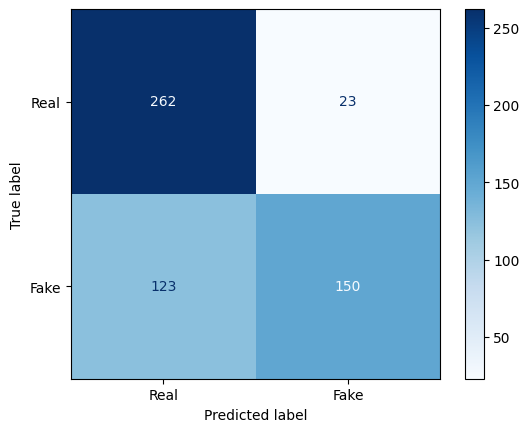

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

# Filter ground-truth labels present in this dataset
y_true = df_test["LABEL"].values
y_pred = results["Prediction"].map(classifier.reverse_label_map).values

# Only evaluate over classes actually present
present_labels = sorted(np.unique(y_true))
present_names = [classifier.label_map[i] for i in present_labels]

print("Evaluating only classes present in benchmark:", present_names)
print(classification_report(y_true, y_pred, labels=present_labels, target_names=present_names))

cm = confusion_matrix(y_true, y_pred, labels=present_labels)
ConfusionMatrixDisplay(cm, display_labels=present_names).plot(cmap="Blues")


In [ ]:
from sklearn.metrics import accuracy_score
acc = accuracy_score(y_true, y_pred)
print(f"Benchmark accuracy: {acc:.3f}")


Benchmark accuracy: 0.720


Text(0.5, 1.0, 'Probability distribution (benchmark)')

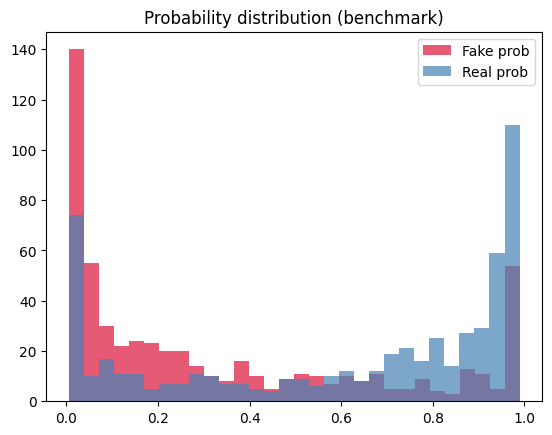

In [ ]:
import matplotlib.pyplot as plt
plt.hist(results["Prob_Fake"], bins=30, color="crimson", alpha=.7, label="Fake prob")
plt.hist(results["Prob_Real"], bins=30, color="steelblue", alpha=.7, label="Real prob")
plt.legend(); plt.title("Probability distribution (benchmark)")


In [ ]:
print("Train avg len:", df["CORPUS"].str.split().str.len().mean())
print("Test avg len:", df_test["CORPUS"].str.split().str.len().mean())


Train avg len: 434.04490057729316
Test avg len: 532.6363636363636
